## Question 1

In [ ]:
pip install -r requirements.txt

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, zero_one_loss
import matplotlib.pyplot as plt

In [21]:
df = pd.read_csv('spambase/spambase.data', header=None)

columns = [
    'word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d',
    'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet',
    'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will',
    'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free',
    'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit',
    'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money',
    'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650',
    'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857',
    'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology',
    'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 'word_freq_direct',
    'word_freq_cs', 'word_freq_meeting', 'word_freq_original', 'word_freq_project',
    'word_freq_re', 'word_freq_edu', 'word_freq_table', 'word_freq_conference',
    'char_freq_;', 'char_freq_(', 'char_freq_[', 'char_freq_!',
    'char_freq_$', 'char_freq_#',
    'capital_run_length_average', 'capital_run_length_longest',
    'capital_run_length_total', 'spam'
]

df.columns = columns

In [22]:
## Split data for training

X = df.drop(columns="spam")
y = df['spam']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=1
)

## Question 1.1

In [23]:
## Train DT for information gain

model = DecisionTreeClassifier(criterion='entropy', random_state=1)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [24]:
## Report metrics

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

print(f"train_error: {zero_one_loss(y_train, y_train_pred):.4f}")
print(f"test_error: {zero_one_loss(y_test, y_test_pred):.4f}")
print(f"train_accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"test_accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"train_f1: {f1_score(y_train, y_train_pred):.4f}")
print(f"test_f1: {f1_score(y_test, y_test_pred):.4f}")
print(f"train_auc: {roc_auc_score(y_train, y_train_prob):.4f}")
print(f"test_auc: {roc_auc_score(y_test, y_test_prob):.4f}")


train_error: 0.0003
test_error: 0.0712
train_accuracy: 0.9997
test_accuracy: 0.9288
train_f1: 0.9996
test_f1: 0.9107
train_auc: 1.0000
test_auc: 0.9288


## Analysis

Overall, these metrics are pretty good for both test and training. The errors are both very low, and the accuracy, f1 score, and auc are very high, Between the test and training metrics all have a different of about 0.07

## Question 1.2

In [25]:
## Train DT for gini index

model = DecisionTreeClassifier(criterion='gini', random_state=1)

model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",1
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

In [26]:
## Report metrics

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_prob = model.predict_proba(X_train)[:, 1]
y_test_prob = model.predict_proba(X_test)[:, 1]

print(f"train_error: {zero_one_loss(y_train, y_train_pred):.4f}")
print(f"test_error: {zero_one_loss(y_test, y_test_pred):.4f}")
print(f"train_accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"test_accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"train_f1: {f1_score(y_train, y_train_pred):.4f}")
print(f"test_f1: {f1_score(y_test, y_test_pred):.4f}")
print(f"train_auc: {roc_auc_score(y_train, y_train_prob):.4f}")
print(f"test_auc: {roc_auc_score(y_test, y_test_prob):.4f}")


train_error: 0.0003
test_error: 0.0956
train_accuracy: 0.9997
test_accuracy: 0.9044
train_f1: 0.9996
test_f1: 0.8764
train_auc: 1.0000
test_auc: 0.8977


## Analysis

Again these metrics show that the model is performing pretty well. Comparing to the information gain metrics, the training metrics are practically identical. The test statistics, however, are all slightly lower for this model than for the information gain, showing that this model performs slightly worse when looking at new data for this data set.

## Question 1.3

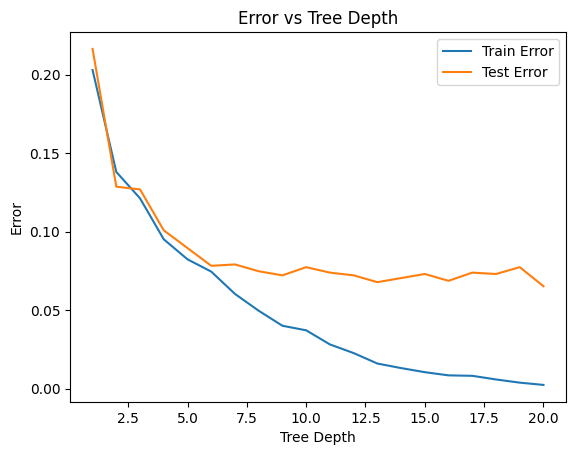

In [27]:
depths = range(1, 21)

train_errors = []
test_errors = []



for d in depths:
    model = DecisionTreeClassifier(
        criterion='entropy',
        max_depth=d,
        random_state=1
    )
    
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_errors.append(zero_one_loss(y_train, y_train_pred))
    test_errors.append(zero_one_loss(y_test, y_test_pred))

# Plot
plt.figure()
plt.plot(depths, train_errors, label="Train Error")
plt.plot(depths, test_errors, label="Test Error")
plt.xlabel("Tree Depth")
plt.ylabel("Error")
plt.title("Error vs Tree Depth")
plt.legend()
plt.show()

## Analysis

From depth 1-5, both training and testing follow about the same values, starting with an error of >.20 and coming down to around 0.07 at around depth 7. After this, training error continues to decrease as the model begins to memorize the data while testing plateaus at that 0.07 error mark. This shows that the best depth value would be about 7, as this has the lowest test error while also being as close to the training error as possible